In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error as mape 
from sklearn.metrics import mean_squared_error as mse
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Test de estacionariedad
def DFtest(serie):
    ''' Una serie es estacionaria si su residuo:
    - Tiene media constante a lo largo del tiempo
    - Tiene varianza constante a lo largo del tiempo (homocedasticidad) 
    - Tiene una autocorrelación constante a lo largo del tiempo
    '''
    print("Resultados del Test de Dickey-Fuller (H0= NO estac.):")
    dftest=adfuller(serie, autolag = "AIC")
    hipotesis_test=['Serie no estacionaria' if dftest[1]>0.025 else 'Serie estacionaria']
    dfoutput=pd.Series([round(dftest[0],4), round(dftest[1]*100, 4), hipotesis_test[0]], index = ["Estadístico", "P-valor(%)", "Hipótesis (α=2,5%)"])
    return dfoutput

# **0. CONTEXTO Y PREPROCESAMIENTO DE DATOS**

Fuente: https://github.com/4GeeksAcademy/alternative-time-series-project/blob/main/README.es.md

**Objetivo**: estimar el ritmo de las ventas, que desde la creación de la empresa ha ido en aumento, para los próximos meses, a fin de proveer el espacio que necesitaremos en una nueva planta

**Descripción de los datos**: Información diaria de ventas de una empresa.

In [3]:
#Cargamos el dataset
serie=pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv")
#Pasamos fecha a datetime y la establecemos como índice
serie["date"]=pd.to_datetime(serie["date"]).dt.normalize() #Normalizamos para poder trabajar mejor con los índices
serie=serie.set_index("date")
#Indicamos la recurrencia de los datos
serie.index.freq = 'D'  # 'M' para mensual, 'D' para diario
serie.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2022-09-03 to 2023-09-03
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   366 non-null    float64
dtypes: float64(1)
memory usage: 5.7 KB


In [4]:
serie.head(10)

,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633
2022-09-08,60.081865
2022-09-09,68.466704
2022-09-10,67.765106
2022-09-11,70.512261


Esta tabla parece indicarnos que tenemos datos con frecuencia diaria.

                  sales
date                   
2022-09-03    55.292157
2023-09-03  1000.482785


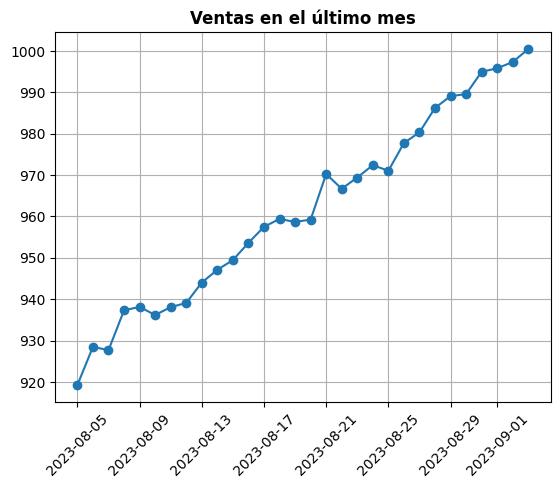

In [5]:
#Mostramos la primera y última venta
print(serie.loc[[serie.index.min(), serie.index.max()]])
#GRaficamente
plt.plot(serie.iloc[-30:], marker='o')
plt.title("Ventas en el último mes", fontweight='bold')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [6]:
#Verificamos valores duplicados
fil_dup=serie.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
fil_fal=int(serie.isna().sum())
#Verificamos valores nulos
print("- No hay filas duplicadas" if fil_dup.sum()==0 else f"- Hay {fil_dup.sum()} filas duplicadas")
print("- No hay filas con datos faltantes" if fil_fal==0 else f"- Hay {fil_fal} filas con datos faltantes")

- No hay filas duplicadas
- No hay filas con datos faltantes


# **1. MODELIZACIÓN**

Las series temporales pueden dividirse en tendencia, estacionalidad y el residuo restante. Vamos a descomponer nuestra serie en dichos componentes.

In [7]:
#Division train-test
train=serie['sales'].iloc[:round(serie.shape[0]*0.8)]
test=serie['sales'].iloc[-round(serie.shape[0]*0.2):]
print("División realizada exitosamente" if (train.index.max()+timedelta(1)==test.index.min()) and (serie.index.max()==test.index.max()) else "Error en la división")

División realizada exitosamente


## 1.1. Descomposición clásica

In [8]:
#Instanciamos el modelo
clasic = seasonal_decompose(train, period = 7) #Trabajamos con datos diarios
##Extraemos la tendencia
tend=clasic.trend
##Extraemos la estacionalidad
esta=clasic.seasonal
##Extraemos el residuo
resid=clasic.resid

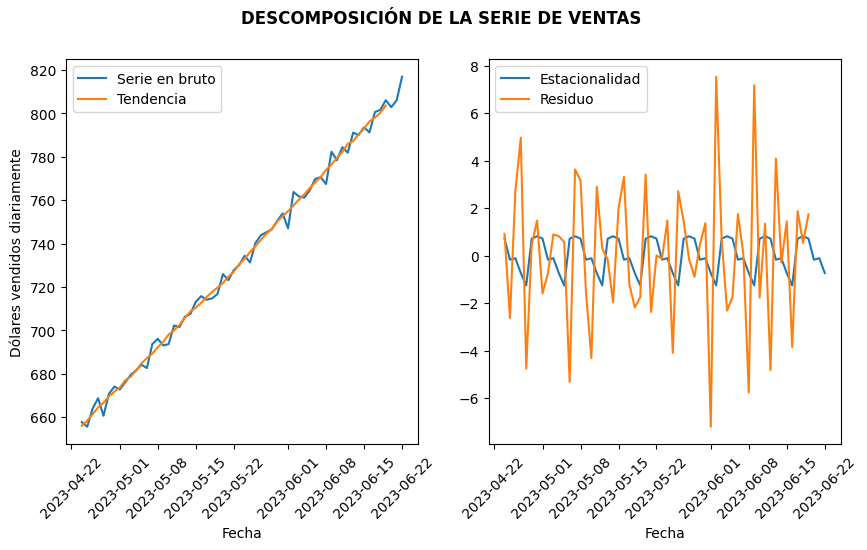

In [9]:
#Mostramos los últimos 2 meses
fig, axis=plt.subplots(1,2, figsize=(10,5))
#Primer gráfico
sns.lineplot(data = train.iloc[-60:], ax=axis[0],label='Serie en bruto')
sns.lineplot(data = tend.iloc[-60:], ax=axis[0], label='Tendencia')
axis[0].set_ylabel("Dólares vendidos diariamente")
axis[0].set_xlabel("Fecha")
axis[0].tick_params(axis='x', labelrotation=45)
#Segundo gráfico
sns.lineplot(data = esta.iloc[-60:], ax=axis[1],label='Estacionalidad')
sns.lineplot(data = resid.iloc[-60:], ax=axis[1],label='Residuo')
axis[1].set_ylabel("")
axis[1].set_xlabel("Fecha")
axis[1].tick_params(axis='x', labelrotation=45)
#Genral
fig.suptitle("DESCOMPOSICIÓN DE LA SERIE DE VENTAS", fontweight='bold')
plt.legend()
plt.show()

Se aprecia como el ajuste de esta descomposición clásica a los datos es bastante bueno, pues el residuo resultante parece ser ruido blanco.

In [10]:
#Testamos si el residuo es estacionario
print(DFtest(resid.dropna()))

Resultados del Test de Dickey-Fuller (H0= NO estac.):
Estadístico                      -8.6109
P-valor(%)                           0.0
Hipótesis (α=2,5%)    Serie estacionaria
dtype: object


In [11]:
#Realizamos predicciones extrapolando los valores de tendecia y estacionalidad con una regresión lineal
#Tendencia
y_tend=tend.dropna().values
X_tend=np.array(range(len(y_tend))).reshape(-1,1) #Convertimos en columna
model_tend = LinearRegression().fit(X_tend, y_tend)
##Predicción de la tendencia
dias=int(len(test)+tend.isna().sum()/2) #valores nulos en train
X_futuro=np.array(range(len(y_tend), len(y_tend)+dias)).reshape(-1,1)
tend_futuro=model_tend.predict(X_futuro)[int(tend.isna().sum()/2):] #eliminamos los valores nulo de train

#Estacionalidad: Extrapolamos los ultimos valores de train para el nuevo conjunto
esta_futuro=np.tile(esta[-7:].values, int(np.ceil(len(test)/7)))[:len(test)] #correción del redondeo del ciclo de np.ceil

#Predicción
clasic_pred=tend_futuro+esta_futuro
#Añadimos fechas
clasic_pred=pd.Series(clasic_pred, index=test.index)

## 1.2. Descomposición STL

In [12]:
stl = STL(train, period=7).fit() #Trabajamos con datos diarios
##Extraemos la tendencia
tend=stl.trend
##Extraemos la estacionalidad
esta=stl.seasonal
##Extraemos el residuo
resid=stl.resid

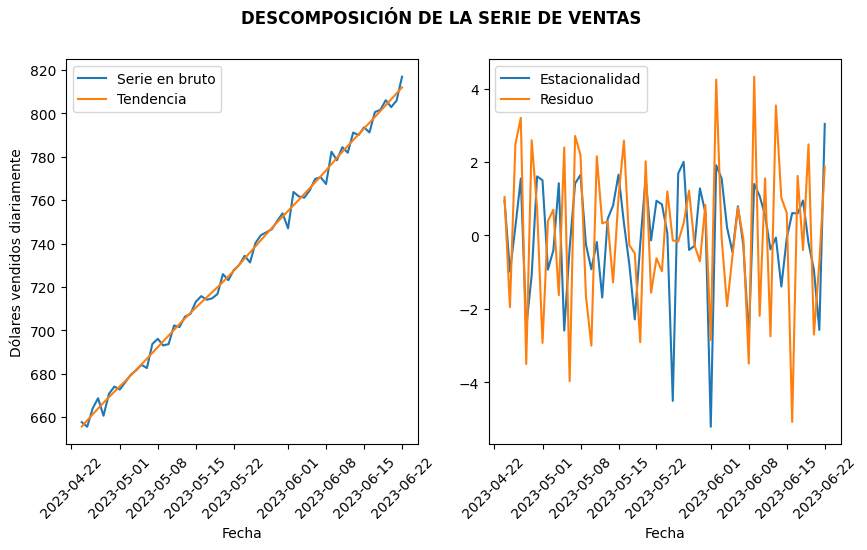

In [13]:
#Mostramos los últimos 2 meses
fig, axis=plt.subplots(1,2, figsize=(10,5))
#Primer gráfico
sns.lineplot(data = train.iloc[-60:], ax=axis[0],label='Serie en bruto')
sns.lineplot(data = tend.iloc[-60:], ax=axis[0], label='Tendencia')
axis[0].set_ylabel("Dólares vendidos diariamente")
axis[0].set_xlabel("Fecha")
axis[0].tick_params(axis='x', labelrotation=45)
#Segundo gráfico
sns.lineplot(data = esta.iloc[-60:], ax=axis[1],label='Estacionalidad')
sns.lineplot(data = resid.iloc[-60:], ax=axis[1],label='Residuo')
axis[1].set_ylabel("")
axis[1].set_xlabel("Fecha")
axis[1].tick_params(axis='x', labelrotation=45)
#Genral
fig.suptitle("DESCOMPOSICIÓN DE LA SERIE DE VENTAS", fontweight='bold')
plt.legend()
plt.show()

In [14]:
#Testamos si el residuo es estacionario
print(DFtest(resid.dropna()))

Resultados del Test de Dickey-Fuller (H0= NO estac.):
Estadístico                     -10.3275
P-valor(%)                           0.0
Hipótesis (α=2,5%)    Serie estacionaria
dtype: object


In [15]:
#Realizamos predicciones extrapolando los valores de tendecia y estacionalidad con una regresión lineal
#Tendencia
y_tend=tend.dropna().values
X_tend=np.array(range(len(y_tend))).reshape(-1,1) #Convertimos en columna
model_trend = LinearRegression().fit(X_tend, y_tend)
##Predicción de la tendencia
dias=int(len(test)+tend.isna().sum()/2) #valores nulos en train
X_futuro=np.array(range(len(y_tend), len(y_tend)+dias)).reshape(-1,1)
tend_futuro=model_trend.predict(X_futuro)[int(tend.isna().sum()/2):] #eliminamos los valores nulo de train

#Estacionalidad: Extrapolamos los ultimos valores de train para el nuevo conjunto
esta_futuro=np.tile(esta[-7:].values, int(np.ceil(len(test)/7)))[:len(test)] #correción del redondeo del ciclo de np.ceil

#Predicción
stl_pred=tend_futuro+esta_futuro
#Añadimos fechas
stl_pred=pd.Series(stl_pred, index=test.index)

## 1.3. Modelo SARIMA

### A) Modelo manual

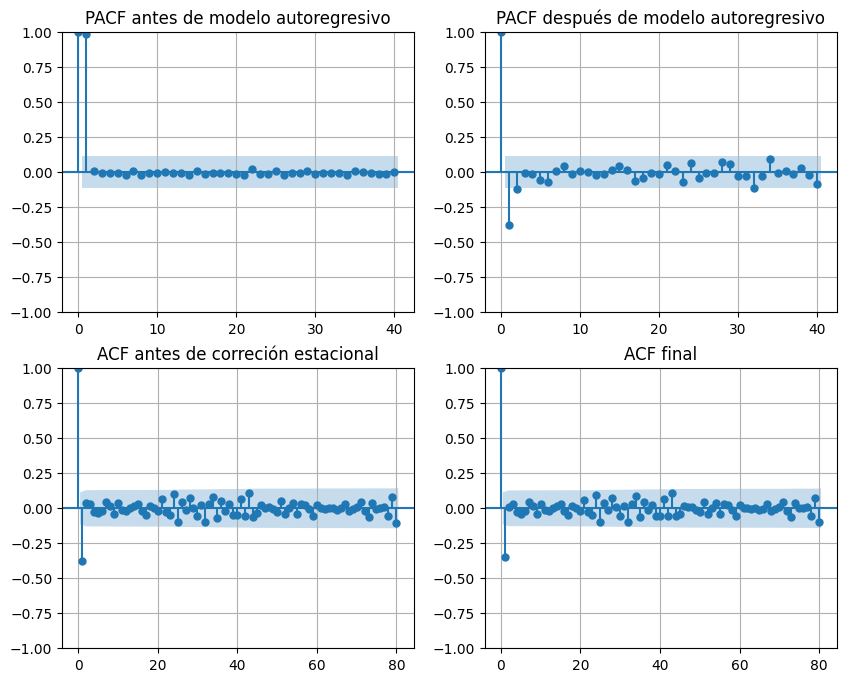

In [16]:
#Entrenamiento
fig,axis=plt.subplots(2, 2, figsize=(10,8))
#PACF antes de AR
plot_pacf(train, lags=40, ax=axis[0,0], title='PACF antes de modelo autoregresivo')
axis[0,0].grid()

#Entrenamos el modelo para extraer residuos (parte no explicada)
arima_man_def0 = SARIMAX(train, order=(1, 0, 0))
arima_man0 = arima_man_def0.fit()

#PACF después de Ar
plot_pacf(arima_man0.resid, lags=40, ax=axis[0,1], title='PACF después de modelo autoregresivo')
axis[0,1].grid()

#ACF antes de sMA
plot_acf(arima_man0.resid, lags=80, ax=axis[1,0], title='ACF antes de correción estacional')
axis[1,0].grid()

#Nuevo modelos para explicar la parte estacional
arima_man_def1 = SARIMAX(train, order=(1, 0, 1))
arima_man1 = arima_man_def1.fit()

#ACF después de sMA
plot_acf(arima_man1.resid, lags=80, ax=axis[1,1], title='ACF final')
axis[1,1].grid()

plt.show()

In [17]:
#Verificamos que los elementos del modelo son significativo individualmente
arima_man_def = SARIMAX(train, order=(1, 0, 1), seasonal_order=(0,0,1,7))
arima_man = arima_man_def.fit()
arima_man.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                             sales   No. Observations:                  293
Model:             SARIMAX(1, 0, 1)x(0, 0, 1, 7)   Log Likelihood                -873.112
Date:                          vi., 06 feb. 2026   AIC                           1754.225
Time:                                   18:32:48   BIC                           1768.945
Sample:                               09-03-2022   HQIC                          1760.120
                                    - 06-22-2023                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   7.67e-05    1.3e+04      0.000       1.000       1.000
ma.L1         -0.1911      0.075     -2.552      0.011      -0.338      -0.044
ma.S.L7        0.3298      0.059      5.567      0.000       0.214       0.446
sigma2        21.8934      1.877     11.666      0.000      18.215      25.571
===================================================================================
Ljung-Box (L1) (Q):                  58.68   Jarque-Bera (JB):                 2.54
Prob(Q):                              0.00   Prob(JB):                         0.28
Heteroskedasticity (H):               1.10   Skew:                             0.19
Prob(H) (two-sided):                  0.63   Kurtosis:                         2.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Resultados del Test de Dickey-Fuller (H0= NO estac.):
Estadístico                      -9.1868
P-valor(%)                           0.0
Hipótesis (α=2,5%)    Serie estacionaria
dtype: object


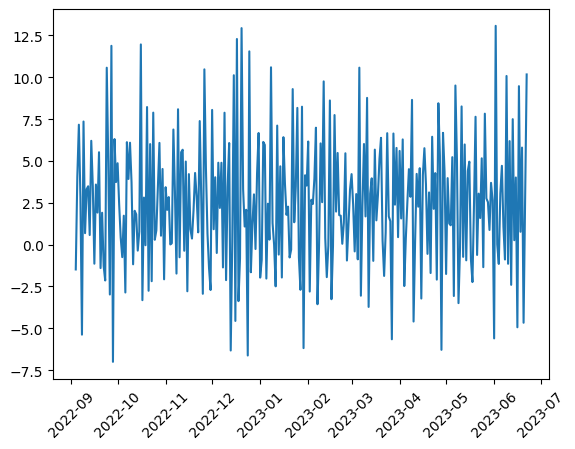

In [18]:
#Testamos que la serie sea estacionaria
print(DFtest(arima_man.resid))
#Mostramos el residuo restante
plt.plot(arima_man.resid[1:])
plt.xticks(rotation=45)
plt.show()

In [19]:
#Realizamos predicciones
arima_man_pred=arima_man.get_prediction(start=test.index[0], end=test.index[-1]).predicted_mean

### B) Modelo automático

In [20]:
#Funcion para hallar arima de forma automatica
arima_auto = auto_arima(train, seasonal = True, trace = True, m = 7)
arima_auto.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=1487.316, Time=1.98 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=1683.985, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=1585.188, Time=0.28 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=1481.310, Time=0.44 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=1773.606, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=1484.235, Time=0.17 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=1482.273, Time=1.56 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=1481.868, Time=0.68 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=1480.664, Time=0.62 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=1482.116, Time=1.22 sec
 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=1479.431, Time=2.56 sec
 ARIMA(0,1,1)(2,0,2)[7] intercept   : AIC=1481.759, Time=3.04 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=inf, Time=2.65 sec
 ARIMA(0,1,0)(2,0,1)[7] intercept   : AIC=1686.958, Time=0.51 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : 

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  293
Model:             SARIMAX(0, 1, 1)x(2, 0, 1, 7)   Log Likelihood                -733.715
Date:                          vi., 06 feb. 2026   AIC                           1479.431
Time:                                   18:33:32   BIC                           1501.491
Sample:                               09-03-2022   HQIC                          1488.267
                                    - 06-22-2023                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.6040      0.509      7.078      0.000       2.606       4.602
ma.L1         -0.9872      0.022    -45.209      0.000      -1.030      -0.944
ar.S.L7       -0.6117      0.171     -3.584      0.000      -0.946      -0.277
ar.S.L14       0.2259      0.061      3.734      0.000       0.107       0.344
ma.S.L7        0.7903      0.174      4.551      0.000       0.450       1.131
sigma2         8.9785      0.839     10.707      0.000       7.335      10.622
===================================================================================
Ljung-Box (L1) (Q):                   1.44   Jarque-Bera (JB):                 1.72
Prob(Q):                              0.23   Prob(JB):                         0.42
Heteroskedasticity (H):               0.96   Skew:                             0.10
Prob(H) (two-sided):                  0.86   Kurtosis:                         2.68
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [21]:
#Realizamos predicción
n_periodos = len(test)
arima_auto_pred=arima_auto.predict(n_periods=n_periodos)

### C) Selección

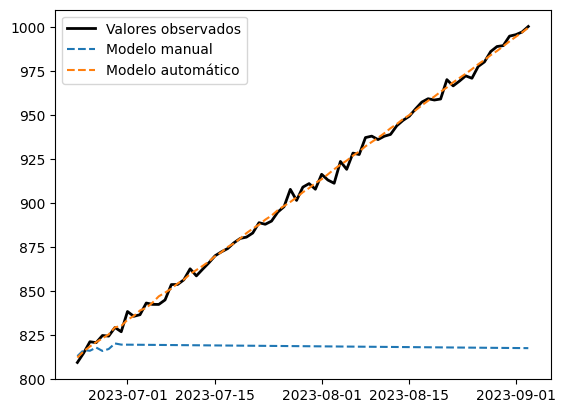

In [22]:
#Gráficamente
plt.plot(test, color="black", label='Valores observados', linewidth=2)
plt.plot(arima_man_pred, label='Modelo manual', linestyle='--')
plt.plot(arima_auto_pred, label='Modelo automático', linestyle='--')
plt.legend()
plt.show()

In [23]:
#Comparamos prediccón de cada modelo
arima_man_mape=round(mape(test, arima_man_pred)*100,2)
arima_auto_mape=round(mape(test, arima_auto_pred)*100,2)
##Mostramos resultado
print(f'MAPE Modelo manual: {arima_man_mape}%')
print(f'MAPE Modelo automático: {arima_auto_mape}%')

MAPE Modelo manual: 9.33%
MAPE Modelo automático: 0.23%


Nos quedaremos con la concreción automática del modelo SARIMAX.

## 1.4. Suavizado exponencial

In [24]:
# Entrenamos el modelo (Holt-Winters)
suaviza_def = ExponentialSmoothing(train, 
                             trend='add', # trend='add': Incluye la pendiente (Método de Holt)
                             seasonal='add', # seasonal='add': Incluye ciclos repetitivos (Winters)
                             seasonal_periods=7)

# Ajustar el modelo (aquí se calculan alpha, beta y gamma automáticamente)
suaviza = suaviza_def.fit()

Resultados del Test de Dickey-Fuller (H0= NO estac.):
Estadístico                      -18.752
P-valor(%)                           0.0
Hipótesis (α=2,5%)    Serie estacionaria
dtype: object


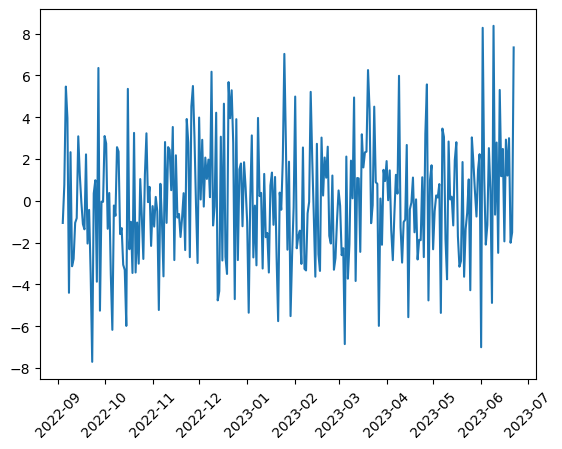

In [25]:
#Testamos que la serie sea estacionaria
print(DFtest(suaviza.resid))
#Mostramos el residuo restante
plt.plot(suaviza.resid[1:])
plt.xticks(rotation=45)
plt.show()

In [26]:
# Predicción
suaviza_pred = suaviza.forecast(steps=len(test)) # forecast es el método más directo para predicciones fuera de la muestra

## 1.5.Selección del modelo

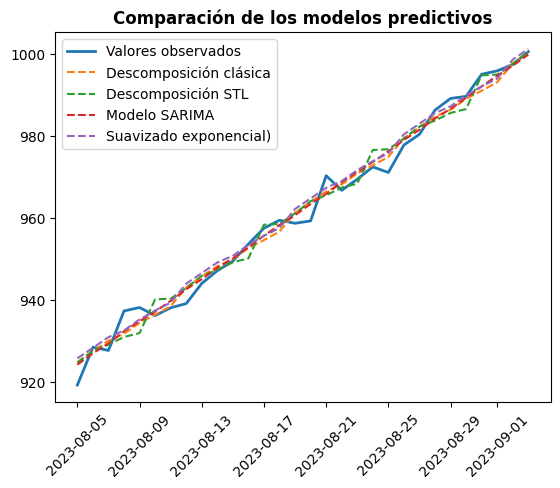

                       MAPE (%)  RSME ($)
Decomposición clásica    0.2301    2.6656
SARIMA                   0.2343    2.6732
Suavizado Exponencial    0.2603    2.8405
Descomposición STL       0.2778    3.1852


In [28]:
#Comparción gráfica
plt.plot(test.iloc[-30:],label='Valores observados', linewidth=2)
plt.plot(clasic_pred.iloc[-30:], label='Descomposición clásica', linestyle='--')
plt.plot(stl_pred.iloc[-30:], label='Descomposición STL', linestyle='--')
plt.plot(arima_auto_pred.iloc[-30:], label='Modelo SARIMA', linestyle='--')
plt.plot(suaviza_pred.iloc[-30:], label='Suavizado exponencial)', linestyle='--')
plt.legend()
plt.xticks(rotation=45)
plt.title('Comparación de los modelos predictivos',fontweight='bold')
plt.show()

#Capturamos MAPE Y RSME
metricas=[]
for pred in [clasic_pred,stl_pred,arima_auto_pred,suaviza_pred]:
    valor_mape=round(mape(test, pred)*100, 4)
    valor_rmse=round(np.sqrt(mse(test, pred)), 4)
    metricas.append([valor_mape, valor_rmse])
print(pd.DataFrame(metricas, index=['Decomposición clásica', 'Descomposición STL', 'SARIMA', 'Suavizado Exponencial'], 
                                    columns=['MAPE (%)', 'RSME ($)']).sort_values(by='MAPE (%)'))

Podemos observar como lo modelos que presentan un menor error son la descomposición clásica y el modelo SARIMA. Para la seleccionar la concrecion con menor error, analizameros los últimos 30 días.

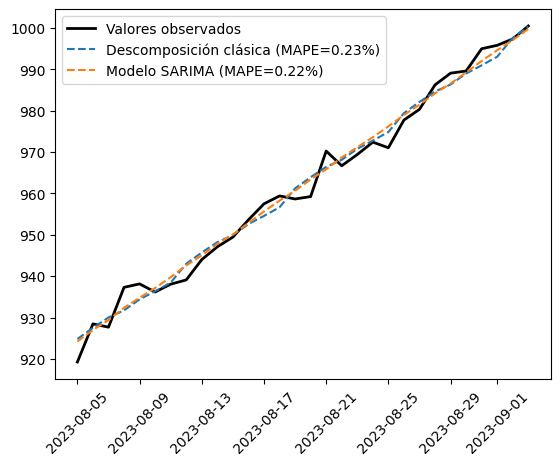

In [29]:
plt.plot(test.iloc[-30:], color="black", label='Valores observados', linewidth=2)
plt.plot(clasic_pred.iloc[-30:], label=f'Descomposición clásica (MAPE={round(mape(test.iloc[-30:], clasic_pred.iloc[-30:])*100,2)}%)', linestyle='--')
plt.plot(arima_auto_pred.iloc[-30:], label=f'Modelo SARIMA (MAPE={round(mape(test.iloc[-30:], arima_auto_pred.iloc[-30:])*100,2)}%)', linestyle='--')
plt.legend()
plt.xticks(rotation=45)
plt.show()

Nos quedaremos con el modelo SARIMA pues presenta un menor error en el último mes.

In [30]:
#Exportamos el modelo con joblib (más rápido que pickle)
joblib.dump(arima_auto, "10-ARIMA.joblib")

['10-ARIMA.joblib']